In [1]:
from data_processing import data_load
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import shap

In [2]:
data_dict = data_load()

In [3]:
# Load your data X, y here
X_train, X_test, y_train, y_test = data_dict["Model"]

model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, enable_categorical=True, tree_method='hist', colsample_bytree=0.8)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"""Accuracy: {accuracy_score(y_test, y_pred)} 
Precision: {precision_score(y_test,y_pred)} 
Recall: {recall_score(y_test,y_pred)} 
f1 Score: {f1_score(y_test,y_pred)}""")

Accuracy: 0.8152173913043478 
Precision: 0.84 
Recall: 0.8235294117647058 
f1 Score: 0.8316831683168316


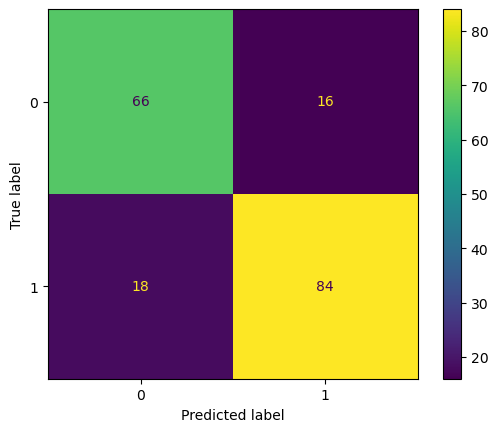

In [4]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

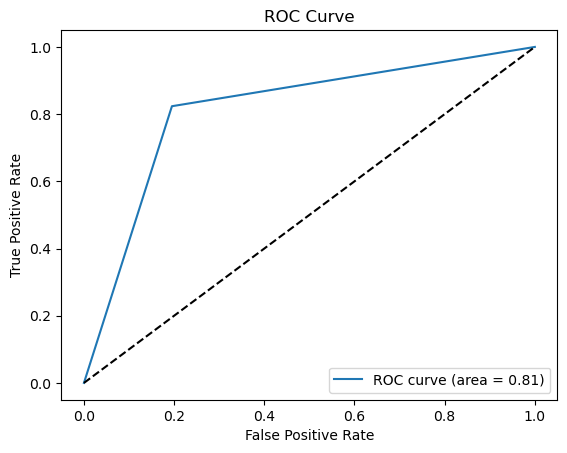

In [5]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [6]:
shap_data = data_dict["Shap"]
explainer = shap.Explainer(model) 

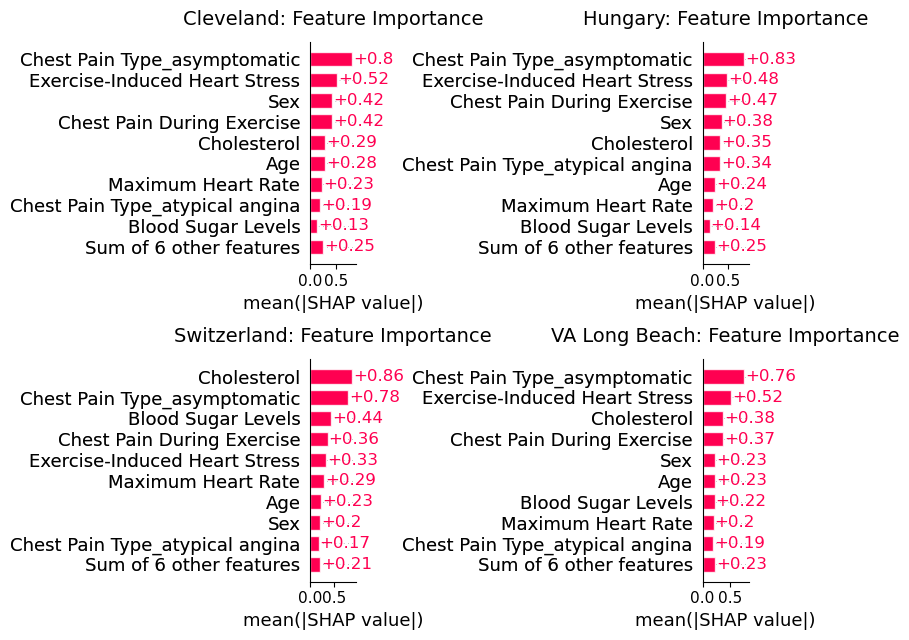

In [16]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 16))
axes = axes.flatten()

for i, (location_name, X) in enumerate(shap_data):
    ax = axes[i]
    
    # Calculate SHAP values for this specific region
    shap_values = explainer(X)
    
    # Tell Matplotlib to make this specific subplot the "active" one
    plt.sca(ax)
    
    # Draw the SHAP plot on the active axis
    shap.plots.bar(shap_values, show=False)
    plt.title(f"{location_name}: Feature Importance", fontsize=14, pad=12)

plt.tight_layout()
plt.show()

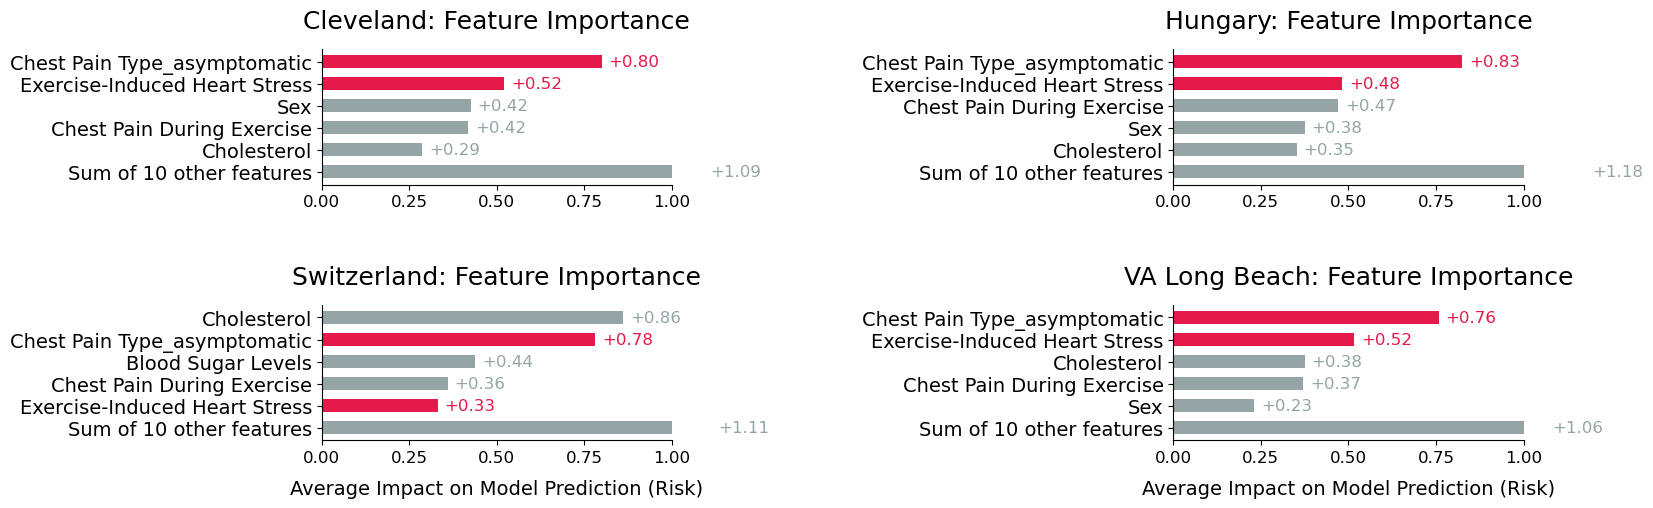

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Define our "Spotlight" features and colors
# (These names must match exactly how they appear in your DataFrame)
spotlight_features = ['Chest Pain Type_asymptomatic', 'Exercise-Induced Heart Stress']
color_spotlight = '#e6194b' # Vibrant Red to match your local plots
color_neutral = '#95a5a6'   # Slate Grey so the red stands out

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 6))
axes = axes.flatten()

for i, (location_name, X) in enumerate(shap_data):
    ax = axes[i]
    
    # Calculate SHAP values for this location
    shap_values = explainer(X)
    
    # Extract the raw values (handling different SHAP version outputs safely)
    vals = shap_values.values if hasattr(shap_values, 'values') else shap_values
    if len(vals.shape) == 3: # If 3D array, extract the positive class
        vals = vals[:, :, 1]
        
    # Calculate mean absolute SHAP values for global importance
    mean_abs_shap = np.abs(vals).mean(axis=0)
    
    # Create a DataFrame to easily sort features and map colors
    df_imp = pd.DataFrame({
        'Feature': X.columns,
        'Importance': mean_abs_shap
    })
    
   # 1. Sort descending so the most important features are at the top
    df_imp = df_imp.sort_values(by='Importance', ascending=False)
    
    # 2. Split into the Top 5 and "Everything Else"
    df_top5 = df_imp.head(5).copy()
    df_rest = df_imp.iloc[5:]
    
    # 3. Calculate the sum and count of the remaining features
    sum_rest = df_rest['Importance'].sum()
    num_rest = len(df_rest)
    
    # 4. Create the new "Sum" row
    df_sum = pd.DataFrame({
        'Feature': [f'Sum of {num_rest} other features'], 
        'Importance': [sum_rest]
    })
    
    # 5. Combine them: We put the "Sum" row first (so it plots at the bottom),
    # and reverse the Top 5 (so the #1 feature plots at the very top)
    df_final = pd.concat([df_sum, df_top5.iloc[::-1]], ignore_index=True)
    
    # 6. Assign colors: Red if in spotlight list, otherwise Grey (the Sum bar will be grey)
    colors = [color_spotlight if feat in spotlight_features else color_neutral 
              for feat in df_final['Feature']]
    
    # Plot the horizontal bars using our new df_final
    bars = ax.barh(df_final['Feature'], df_final['Importance'], color=colors, height=0.6)
    
    # Add the numeric values (+0.XX) to the end of each bar
    for bar in bars:
        width = bar.get_width()
        # Add text slightly to the right of the bar edge
        ax.text(width + 0.02, bar.get_y() + bar.get_height()/2,
                f'+{width:.2f}', 
                ha='left', va='center', fontsize=12, color=bar.get_facecolor())
    
    # --- Format the Axes for the Poster ---
    ax.set_title(f"{location_name}: Feature Importance", fontsize=18, pad=15)
    
    # 2. Unify the X-Axis scale across all four plots
    ax.set_xlim(0, 1.0) 
    
    # 3. Fix the "0.00.5" overlap by explicitly setting the tick marks
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0]) 
    
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='x', labelsize=12)
    
    # Clean up the borders for a modern look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 4. Use a plain English x-axis label (only on the bottom plots to save space)
    if i >= 2:
        ax.set_xlabel('Average Impact on Model Prediction (Risk)', fontsize=14, labelpad=10)

# Adjust layout to prevent clipping
plt.tight_layout(pad=4.0) 
plt.savefig('clinic_interp.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

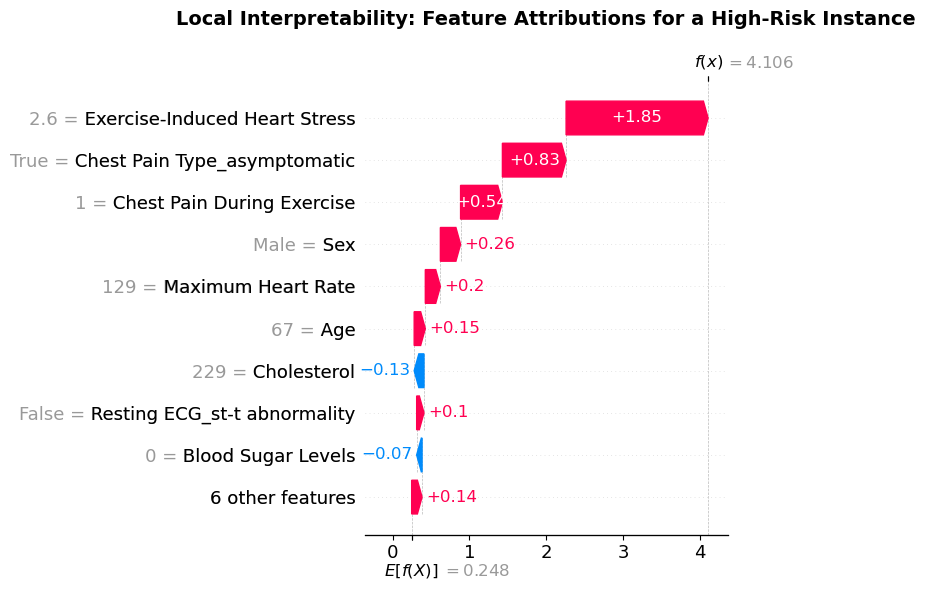

In [35]:
# At-Risk Patient
cleveland_data = shap_data[0][1]
shap_values = explainer(cleveland_data)

plt.rcParams.update({'font.size': 10})

# 1. Generate the original SHAP waterfall plot but tell it NOT to show yet
shap.plots.waterfall(shap_values[2], show=False)

# 2. Add a quality, bold title with some padding so it doesn't crowd the top label
plt.title("Local Interpretability: Feature Attributions for a High-Risk Instance", fontsize=14, fontweight='bold', pad=20)

fig = plt.gcf()
fig.set_size_inches(8, 6) #

# 3. Ensure everything fits nicely without getting cut off
plt.tight_layout()

# 4. Save the figure with high resolution and a transparent background for your poster
plt.savefig('high_risk_waterfall.png', dpi=300, bbox_inches='tight', transparent=True)

# 5. Finally, display the plot
plt.show()

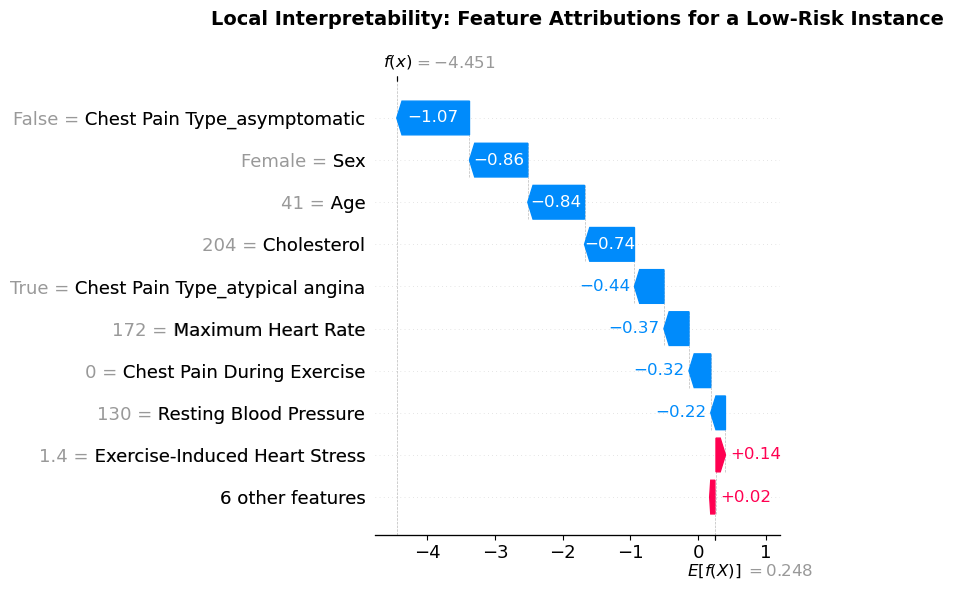

In [36]:
# Healthy Patient
cleveland_data = shap_data[0][1]
shap_values = explainer(cleveland_data)

plt.rcParams.update({'font.size': 10})

# 1. Generate the original SHAP waterfall plot but tell it NOT to show yet
shap.plots.waterfall(shap_values[4], show=False)

# 2. Add a quality, bold title with some padding so it doesn't crowd the top label
plt.title("Local Interpretability: Feature Attributions for a Low-Risk Instance", fontsize=14, fontweight='bold', pad=20)

fig = plt.gcf()
fig.set_size_inches(8, 6) #

# 3. Ensure everything fits nicely without getting cut off
plt.tight_layout()

# 4. Save the figure with high resolution and a transparent background for your poster
plt.savefig('low_risk_waterfall.png', dpi=300, bbox_inches='tight', transparent=True)

# 5. Finally, display the plot
plt.show()